# Libraries Import

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


# Load Dataset

In [4]:
# Load the Unemployment in India dataset
df = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/OIBSIP/OIBSIP-DataScience-Task2-Unemployment-Analysis/Unemployment_in_India.csv")

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


# Understand Dataset

In [6]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Cleaned Column Names:")
print(df.columns.tolist())


Cleaned Column Names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [7]:
print("First 5 Rows:")
df.head()


First 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
print("Last 5 Rows:")
df.tail()


Last 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("Data Types:")
print(df.dtypes)


Data Types:
Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object


# EDA

In [10]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 768
Number of Columns: 7


In [11]:
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [12]:
print("Descriptive Statistics:")
df.describe()


Descriptive Statistics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [13]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [14]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 27


In [15]:
print("Unique Regions:")
print(df["Region"].unique())


Unique Regions:
<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str


In [16]:
print("\nNumber of Regions:", df["Region"].nunique())
print("\nArea Distribution:")
print(df["Area"].value_counts())



Number of Regions: 28

Area Distribution:
Area
Urban    381
Rural    359
Name: count, dtype: int64


# Data Cleaning

In [17]:
# Convert Date into datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remove rows with invalid dates
df = df.dropna(subset=["Date"])

# Standardize text columns
df["Region"] = df["Region"].str.strip()
df["Area"] = df["Area"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()

print("Date type:", df["Date"].dtype)


Date type: datetime64[us]


/var/folders/cy/sgcgtsjj4ns31pvk0g2rrs5h0000gn/T/ipykernel_87422/2562315429.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [18]:
# Check the cleaned dataset
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:", df.duplicated().sum())


Missing Values After Cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate Rows After Cleaning: 0


In [19]:
# Create useful time-based columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


# Exploratory Analysis

In [20]:
print("Average Unemployment Rate:",
      round(df["Estimated Unemployment Rate (%)"].mean(), 2), "%")

print("Average Labour Participation Rate:",
      round(df["Estimated Labour Participation Rate (%)"].mean(), 2), "%")


Average Unemployment Rate: 11.79 %
Average Labour Participation Rate: 42.63 %


In [21]:
# Region-wise average unemployment rate
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg.head(10)


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

# Visualisations

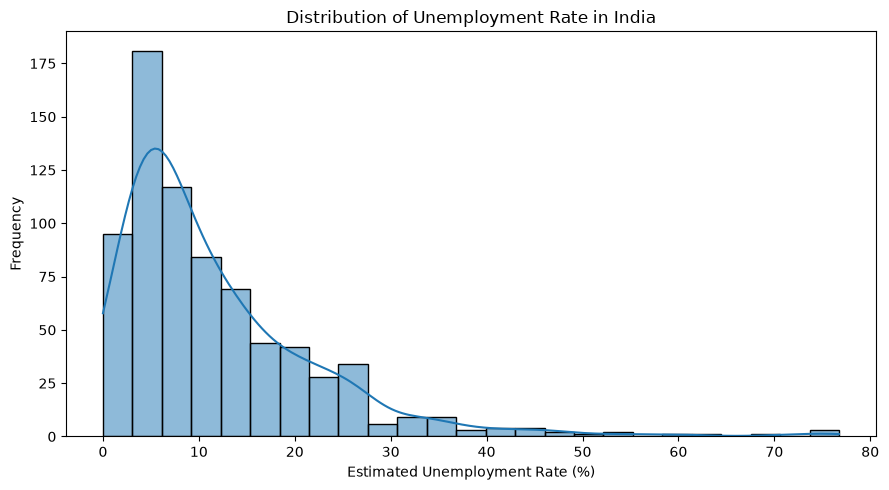

In [22]:
# Distribution of unemployment rate
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Estimated Unemployment Rate (%)",
    bins=25,
    kde=True
)

plt.title("Distribution of Unemployment Rate in India")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


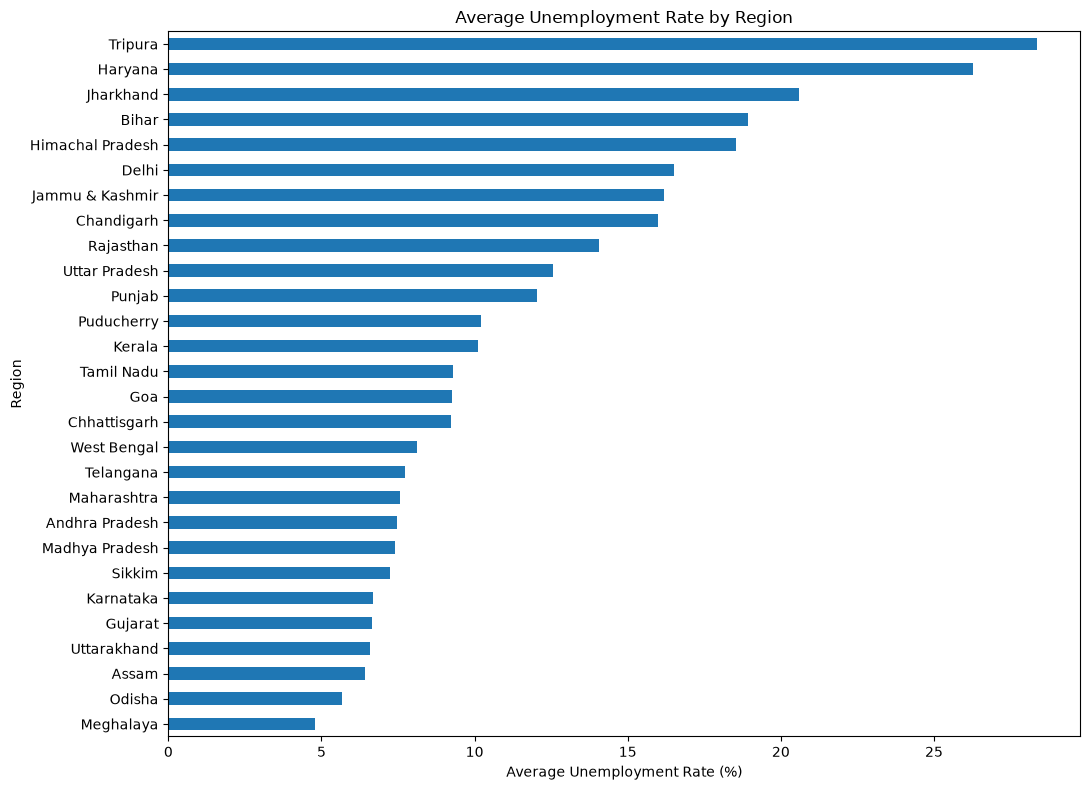

In [23]:
# Region-wise average unemployment rate
plt.figure(figsize=(11, 8))

region_avg.sort_values(ascending=True).plot(
    kind="barh"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()


### Observation

This chart shows how average unemployment differs across Indian regions. 
The regions at the top of the ranking have comparatively higher average unemployment rates.


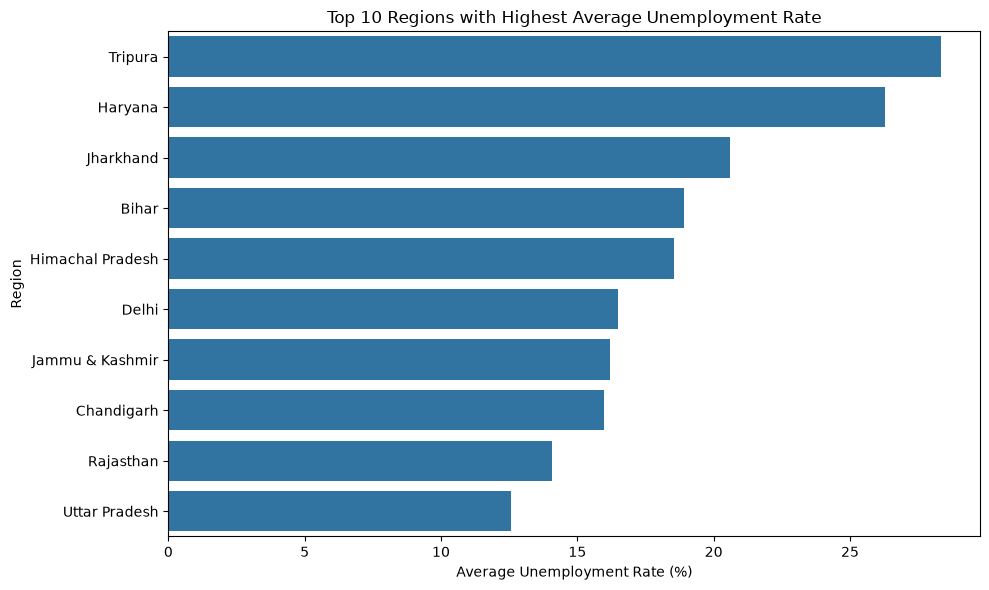

In [24]:
# Top 10 regions with the highest average unemployment rate
top_10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10.values,
    y=top_10.index,
    errorbar=None
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()


### Observation

The top 10 regions provide a focused view of the areas with the highest average unemployment rates in the dataset.


# Time-Series Analysis

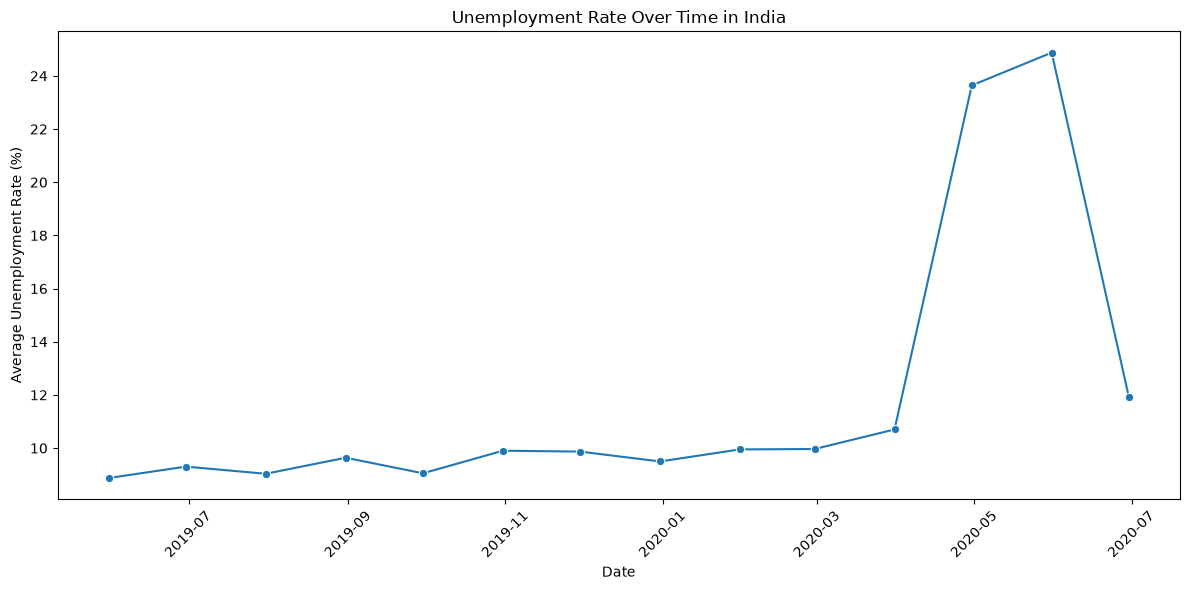

In [25]:
# Overall unemployment trend over time
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_unemployment.index,
    y=monthly_unemployment.values,
    marker="o"
)

plt.title("Unemployment Rate Over Time in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Observation

The time-series chart shows how the average unemployment rate changed over the observed period.


In [26]:
# Select three regions with the most observations
major_regions = df["Region"].value_counts().head(3).index.tolist()

print("Selected Regions:", major_regions)


Selected Regions: ['Andhra Pradesh', 'Bihar', 'Chhattisgarh']


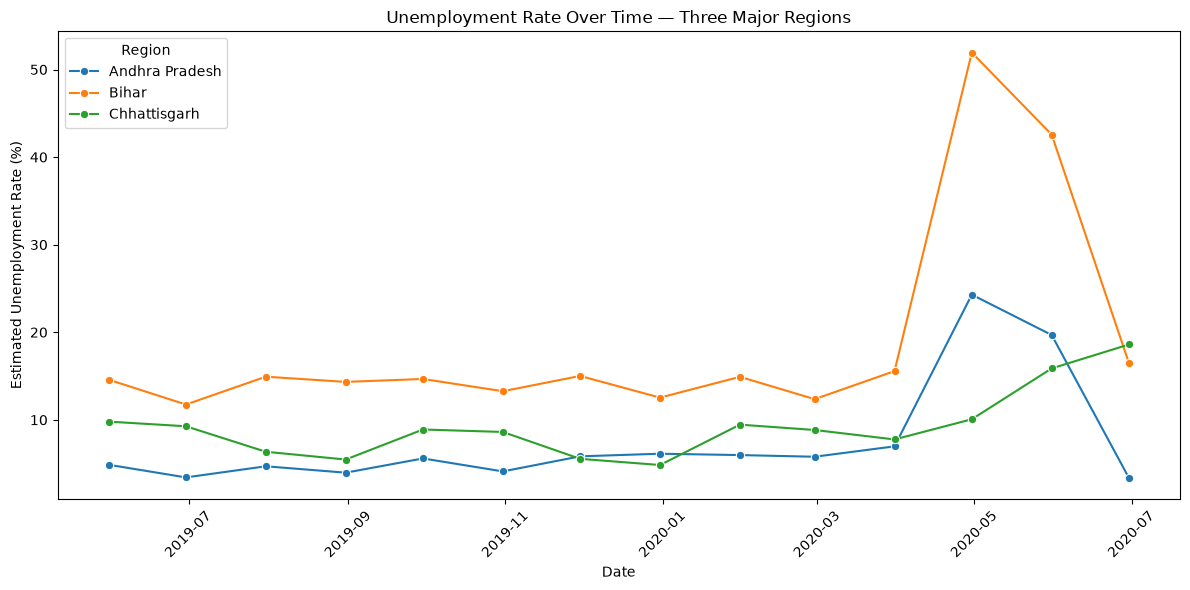

In [27]:
# Time-series comparison of three major regions
region_trend = (
    df[df["Region"].isin(major_regions)]
    .groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=region_trend,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time — Three Major Regions")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Observation

The three-region comparison highlights differences in unemployment trends between regions and makes major changes over time easier to identify.


# COVID-19 Analysis

In [28]:
# Average unemployment rate by year
yearly_unemployment = (
    df.groupby("Year")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

yearly_unemployment


Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64

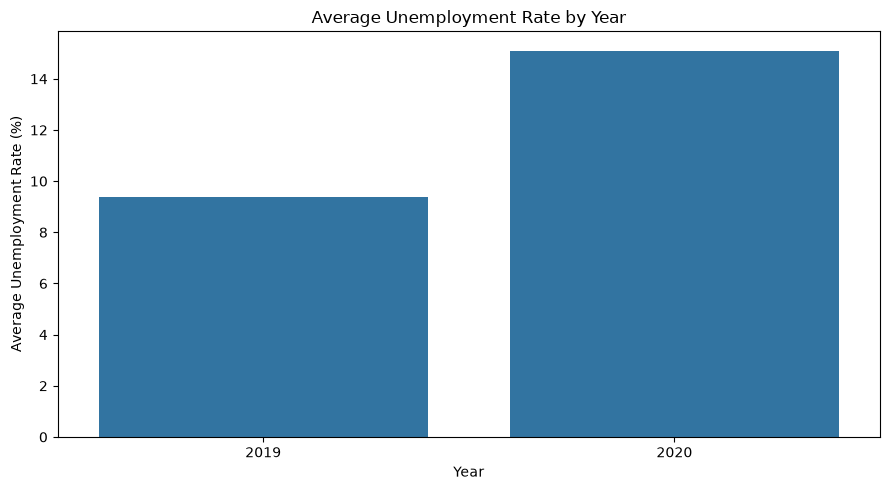

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=yearly_unemployment.index.astype(str),
    y=yearly_unemployment.values,
    errorbar=None
)

plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()


### Observation

The yearly comparison helps identify whether unemployment changed substantially during the period containing the COVID-19 disruption.


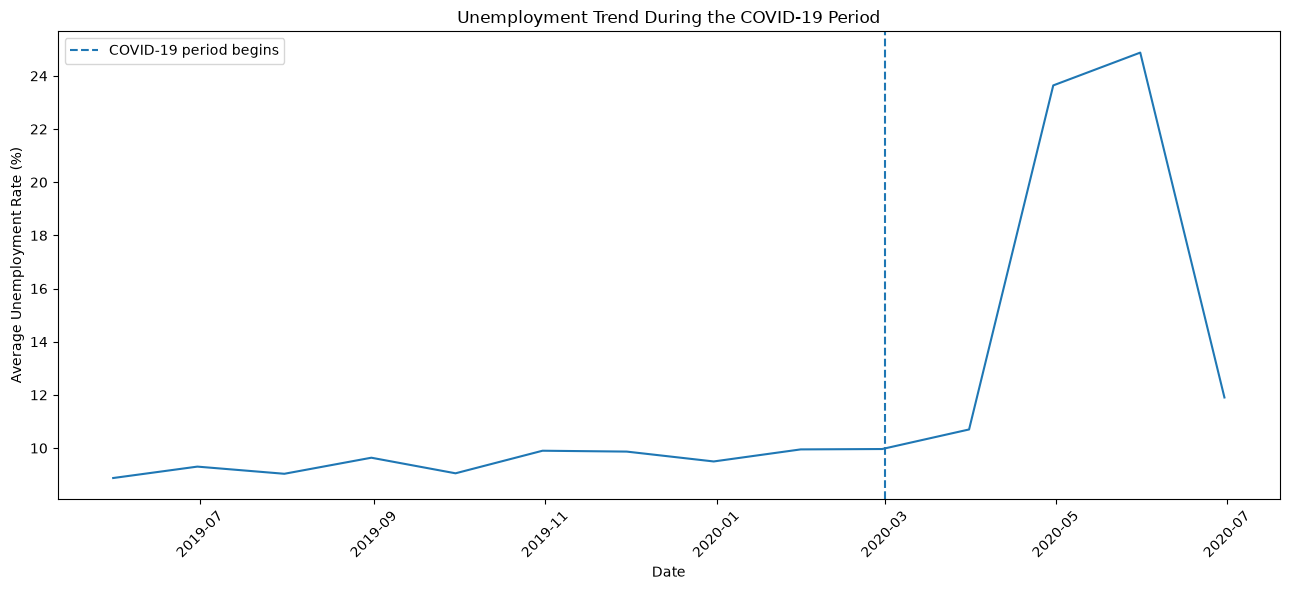

In [30]:
# COVID-era time-series visualization
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    estimator="mean",
    errorbar=None
)

# Approximate start of the major COVID-19 disruption in India
plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="COVID-19 period begins"
)

plt.title("Unemployment Trend During the COVID-19 Period")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Observation

The reference line helps compare the unemployment trend before and during the major COVID-19 disruption.


# Correlation Analysis

In [31]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


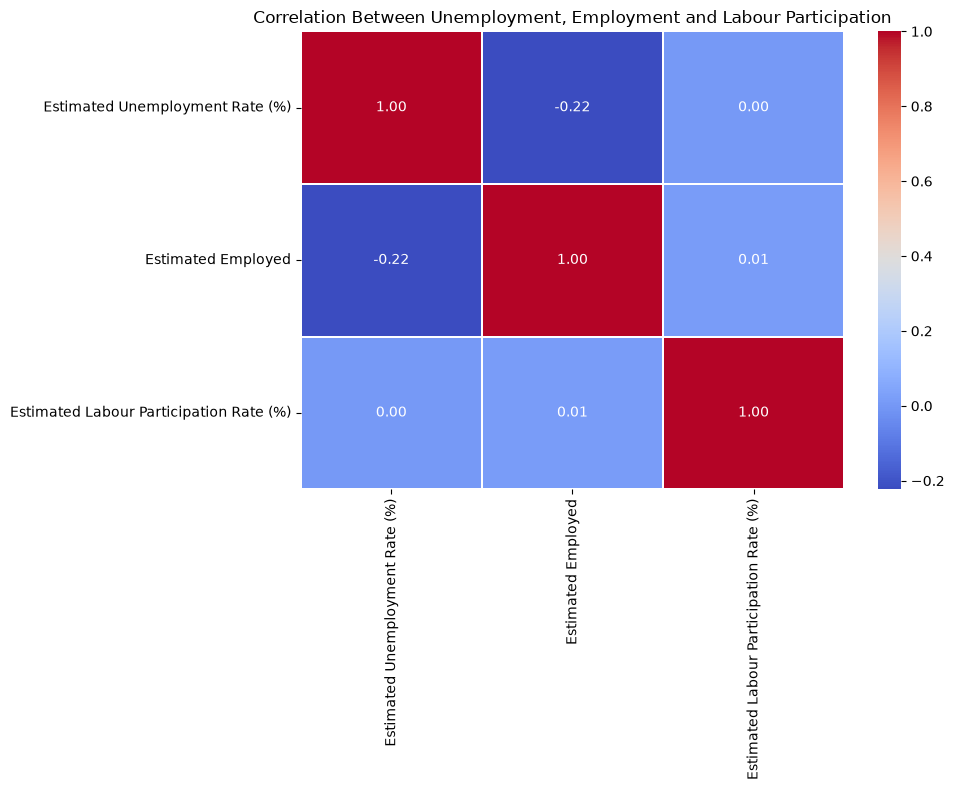

In [43]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.2
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation"
)

plt.tight_layout()
plt.show()


### Observation

The correlation matrix shows the direction and strength of the relationships between unemployment, estimated employment, and labour participation.


# Pre-COVID vs Post-COVID Analysis

In [33]:
# Define the COVID-19 comparison periods
pre_covid = df[df["Date"] < "2020-03-01"].copy()
post_covid = df[df["Date"] >= "2020-03-01"].copy()

print("Pre-COVID rows:", len(pre_covid))
print("Post-COVID rows:", len(post_covid))


Pre-COVID rows: 536
Post-COVID rows: 204


In [34]:
# Calculate mean values for both periods
period_comparison = pd.DataFrame({
    "Pre-COVID": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        pre_covid["Estimated Employed"].mean(),
        pre_covid["Estimated Labour Participation Rate (%)"].mean()
    ],
    "Post-COVID": [
        post_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Employed"].mean(),
        post_covid["Estimated Labour Participation Rate (%)"].mean()
    ]
}, index=[
    "Unemployment Rate (%)",
    "Estimated Employed",
    "Labour Participation Rate (%)"
])

period_comparison


,Pre-COVID,Post-COVID
Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Labour Participation Rate (%),4.388612e+01,3.933005e+01


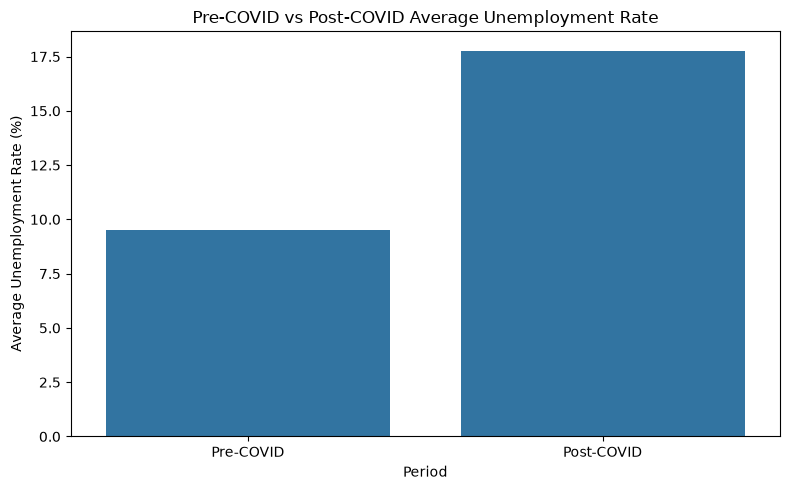

In [35]:
# Visual comparison of unemployment rate
comparison_plot = period_comparison.loc[
    ["Unemployment Rate (%)"]
].T

plt.figure(figsize=(8, 5))

sns.barplot(
    x=comparison_plot.index,
    y="Unemployment Rate (%)",
    data=comparison_plot,
    errorbar=None
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()


### Observation

The comparison shows how the average unemployment rate changed between the pre-COVID and post-COVID periods.


# Regional COVID Comparison

In [36]:
# Compare regional unemployment before and after COVID
regional_period = (
    df.assign(
        Period=np.where(
            df["Date"] < "2020-03-01",
            "Pre-COVID",
            "Post-COVID"
        )
    )
    .groupby(["Region", "Period"])["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)

regional_period.head()


Period,Post-COVID,Pre-COVID
Region,,
Andhra Pradesh,13.576250,5.037500
Assam,6.578571,6.372632
Bihar,31.631250,13.833000
Chandigarh,14.325000,16.325000
Chhattisgarh,13.075000,7.706500


In [37]:
# Show regions with the largest increase in average unemployment
regional_period["Change"] = (
    regional_period["Post-COVID"] -
    regional_period["Pre-COVID"]
)

regional_change = regional_period.sort_values(
    "Change",
    ascending=False
).head(10)

regional_change


Period,Post-COVID,Pre-COVID,Change
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550
Haryana,34.65250,22.9355,11.71700
Kerala,17.95250,6.9925,10.96000
Telangana,15.44250,4.6560,10.78650
Madhya Pradesh,14.07000,4.7410,9.32900


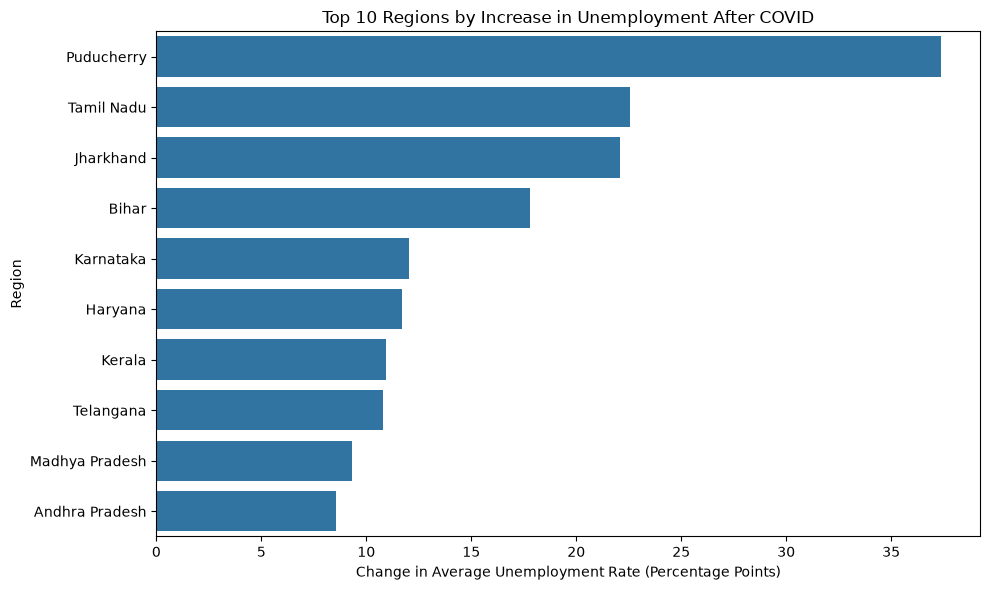

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=regional_change["Change"].values,
    y=regional_change.index,
    errorbar=None
)

plt.title("Top 10 Regions by Increase in Unemployment After COVID")
plt.xlabel("Change in Average Unemployment Rate (Percentage Points)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()


### Observation

This visualization identifies regions where the average unemployment rate increased the most when comparing the two periods.


# Key Findings

In [39]:
# Compact summary of the main numerical findings

highest_region = region_avg.idxmax()
highest_region_rate = region_avg.max()

lowest_region = region_avg.idxmin()
lowest_region_rate = region_avg.min()

pre_rate = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_rate = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Highest Average Unemployment Region:", highest_region)
print("Rate:", round(highest_region_rate, 2), "%")

print("\nLowest Average Unemployment Region:", lowest_region)
print("Rate:", round(lowest_region_rate, 2), "%")

print("\nPre-COVID Average Unemployment:", round(pre_rate, 2), "%")
print("Post-COVID Average Unemployment:", round(post_rate, 2), "%")
print("Change:", round(post_rate - pre_rate, 2), "percentage points")


Highest Average Unemployment Region: Tripura
Rate: 28.35 %

Lowest Average Unemployment Region: Meghalaya
Rate: 4.8 %

Pre-COVID Average Unemployment: 9.51 %
Post-COVID Average Unemployment: 17.77 %
Change: 8.26 percentage points


# Conclusion

## Conclusion

This project analyzed unemployment trends across Indian regions using exploratory data analysis and data visualization.

The analysis covered:

- Regional differences in average unemployment
- The top regions with the highest unemployment rates
- Overall unemployment trends over time
- Comparison of unemployment trends across three regions
- The unemployment trend around the COVID-19 period
- Correlation between unemployment, employment and labour participation
- Pre-COVID vs post-COVID unemployment levels

The results provide a data-driven view of regional and temporal unemployment patterns in India and demonstrate how Python, pandas, matplotlib and seaborn can be used for real-world exploratory data analysis.
